# Pandas Hands-on Lab: From Tables to Real Analysis

## Student Practice Notebook

**Name:** K Harsha Vardhan  
**Register Number:** AP24110011061  
**Date:** 14-08-2026

## Learning Objectives

After completing this lab, you will be able to:

- Load and inspect a real dataset with pandas
- Select, filter, and sort rows and columns
- Create new columns from existing ones
- Explore categorical data with `value_counts()`
- Clean data: handle duplicates, missing values, wrong dtypes, and column names
- Summarize data with `groupby()`
- Combine two related tables with `merge()`
- Visualize a DataFrame with matplotlib
- Save your results back to a file

### How to use this notebook
This continues directly from last week's NumPy lab — pandas is built on top of NumPy arrays, so everything you already know about arrays applies here, just organized into labeled rows and columns (a **DataFrame**).

- **Demonstration** cells: run and read.
- **Practice** cells: write your own code.
- **Predict-then-run**: write your prediction before running.
- **Reflection**: short written answers in your own words.


## Part 1: Loading and Inspecting Data

We'll use the classic **tips** dataset — real restaurant bill data. Each row is one bill.

### Demonstration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 10)
pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**Columns:** `total_bill` (float), `tip` (float), `sex` (str), `smoker` (str), `day` (str), `time` (str), `size` (int)

A pandas **DataFrame** is a 2D table, similar to a NumPy 2D array, but with labeled columns and an index for each row.


In [2]:
print("Shape:", tips.shape)
print("\nInfo:")
tips.info()


Shape: (244, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


### Student Practice

1. Print `tips.describe()` to see summary statistics.
2. Print the column names using `tips.columns`.
3. Print just the last 5 rows using `tips.tail()`.


In [3]:
tips.describe()

,total_bill,tip,size
count,244.000,244.000,244.000
mean,19.786,2.998,2.570
std,8.902,1.384,0.951
min,3.070,1.000,1.000
25%,13.348,2.000,2.000
50%,17.795,2.900,2.000
75%,24.127,3.562,3.000
max,50.810,10.000,6.000


In [4]:
tips.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [5]:
tips.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


**Reflection:** Compare `tips.shape` (NumPy-style) to `tips.info()`. What extra information does `.info()` give you that `.shape` alone doesn't?

*Your answer:*

tips.shape givees size of each dimension and tip.info gives all details of the dataframe such as the number of not-null vlaues and datatype of a column

## Part 2: Exploring Categorical Data with `value_counts()`

Before filtering or grouping, it helps to know what categories exist in a column and how common each is.

### Demonstration


In [6]:
tips['day'].value_counts()


,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


### Student Practice

1. Use `value_counts()` on the `time` column. Which time period has more bills — Lunch or Dinner?
2. Use `value_counts()` on `smoker`. What percentage of customers were smokers? (Hint: `value_counts(normalize=True)` gives proportions instead of counts.)


In [7]:
tips['time'].value_counts()

,count
time,
Dinner,176
Lunch,68


In [8]:
tips['smoker'].value_counts(normalize=True)

,proportion
smoker,
No,0.619
Yes,0.381


## Part 3: Selecting and Filtering

### Demonstration


In [9]:
# Select specific columns
tips[['total_bill','tip']].head()


,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61


In [10]:
# Select rows by position
tips.iloc[0:5]
tips.loc[0:5]


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4


In [11]:
# Select rows by label/condition using .loc
tips.loc[tips['day']=='Sun', ['total_bill','tip','size']].head()


,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4


In [12]:
# Boolean filtering (same idea as NumPy boolean indexing!)
big_tables = tips[tips['size'] >= 5]
big_tables.head()


,total_bill,tip,sex,smoker,day,time,size
125,29.80,4.20,Female,No,Thur,Lunch,6
141,34.30,6.70,Male,No,Thur,Lunch,6
142,41.19,5.00,Male,No,Thur,Lunch,5
143,27.05,5.00,Female,No,Thur,Lunch,6
155,29.85,5.14,Female,No,Sun,Dinner,5


**Note the parallel to NumPy:** `tips[tips['size'] >= 5]` uses a boolean condition to filter rows — exactly like `marks[marks > 60]` did with NumPy arrays in last week's lab. The DataFrame version just keeps the whole row instead of a single value.


### Student Practice — predict then check

Before running, predict: how many rows will `tips[(tips['smoker']=='Yes') & (tips['time']=='Lunch')]` return? You don't need an exact number — just predict whether it will be a small or large subset of the 244 total rows, and why.

*Your prediction:*
there will be only small number of the people as seen in tips['smoker'].value_count(normalize=True) and tips['time'].value_count(), there are only few lunch and less proportion of smokers

In [13]:
tips[(tips['smoker']=='Yes')&(tips['time']=='Lunch')].shape


(23, 7)

## Part 4: Sorting

### Demonstration


In [14]:
tips_sorted = tips.sort_values(['total_bill','tip'], ascending=[False, True])
tips_sorted.head()


,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3


### Student Practice

Sort `tips` by `tip` in descending order and display the top 5 highest tips. Which day(s) do they mostly occur on?


In [15]:
tips_sortedby_tip=tips.sort_values('tip',ascending=False)
tips_sortedby_tip.head(5)['day'].value_counts().idxmax()

'Sat'

## Part 5: Creating New Columns

### Demonstration


In [16]:
tips = tips.assign(
    tip_pct = tips['tip'] / tips['total_bill'],
    tip_per_person = tips['tip'] / tips['size']
)
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct,tip_per_person
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059,0.505
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161,0.553
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167,1.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140,1.655
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147,0.902


### Student Practice

Filter for `day='Sat'` and `size >= 3`, add a new column `bill_per_person = total_bill / size`, then sort descending by that column and show the top 5.


In [17]:
filtered=tips[(tips['day']=='Sat') & tips['size']>=3]
filtered=filtered.assign(bill_per_person=filtered['total_bill']/filtered['size'])
final=filtered.sort_values(['bill_per_person'],ascending=False)
final.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct,tip_per_person,bill_per_person


## Part 6: Cleaning Data

Real data is rarely perfect. We'll cover 4 common cleaning tasks: duplicates, missing values, wrong dtypes, and messy column names.

### 6a. Duplicates


In [18]:
print("Duplicate rows:", tips.duplicated().sum())
tips_clean = tips.drop_duplicates()
print("Shape after dropping duplicates:", tips_clean.shape)


Duplicate rows: 1
Shape after dropping duplicates: (243, 9)


### 6b. Missing Values

Let's deliberately introduce some missing values to practice on, since the original dataset is clean.

In [19]:
tips_messy = tips.copy()
tips_messy.loc[5:8, 'total_bill'] = np.nan
tips_messy.loc[15, 'day'] = np.nan

print("Missing values per column:")
print(tips_messy.isna().sum())


Missing values per column:
total_bill        4
tip               0
sex               0
smoker            0
day               1
time              0
size              0
tip_pct           0
tip_per_person    0
dtype: int64


### Student Practice

1. Drop rows with any missing values using `.dropna()` and check the new shape.
2. Instead of dropping, fill missing `total_bill` values with the column's mean using `.fillna()`. Compare the two approaches — when would you choose one over the other?


In [20]:
tips_messy.shape

(244, 9)

In [21]:
tips_messy.dropna().shape

(239, 9)

### 6c. Fixing Data Types

### Demonstration


In [22]:
tips_dtypes = tips.copy()
print("Before:", tips_dtypes['size'].dtype,tips_dtypes['day'].dtype)

tips_dtypes['size'] = tips_dtypes['size'].astype('int32')
tips_dtypes['day'] = tips_dtypes['day'].astype('category')

print("After:", tips_dtypes['size'].dtype, tips_dtypes['day'].dtype)


Before: int64 object
After: int32 category


### 6d. Renaming Columns

### Demonstration


In [23]:
tips_renamed = tips.rename(columns={'size': 'party_size', 'tip_pct': 'tip_percentage'})
tips_renamed.columns


Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'party_size',
       'tip_percentage', 'tip_per_person'],
      dtype='object')

### Student Practice

Rename `total_bill` to `bill_amount` and `smoker` to `is_smoker` in a copy of `tips`. Print the new column list to confirm.


In [24]:
tips_copy=tips.copy()
tips_copy=tips_copy.rename(columns={'total_bill':'bill_amount','smoker':'is_smoker'})
tips_copy.columns

Index(['bill_amount', 'tip', 'sex', 'is_smoker', 'day', 'time', 'size',
       'tip_pct', 'tip_per_person'],
      dtype='object')

## Part 7: Summarizing with `groupby()`

`groupby()` is one of the most powerful pandas tools — it splits data into groups, applies a calculation to each group, then combines the results. This is the tabular equivalent of the `np.mean()` per-category calculations you'd otherwise have to write manually with loops.

### Demonstration


In [25]:
tips.groupby('day')['total_bill'].mean()


,total_bill
day,
Fri,17.152
Sat,20.441
Sun,21.410
Thur,17.683


In [26]:
# Multiple aggregations at once
tips.groupby('day').agg(
    avg_bill=('total_bill','mean'),
    avg_tip=('tip','mean'),
    n_bills=('total_bill','size')
)


,avg_bill,avg_tip,n_bills
day,,,
Fri,17.152,2.735,19
Sat,20.441,2.993,87
Sun,21.410,3.255,76
Thur,17.683,2.771,62


### Student Practice — predict then check

Predict: will average tip percentage (`tip_pct`) be higher at Lunch or Dinner? Write your guess, then check with `groupby('time')['tip_pct'].mean()`.

*Your prediction:* the avg tip will be higher at lunch


In [27]:
tips.groupby('time')['tip_pct'].mean().idxmax()


'Lunch'

**Reflection:** In your own words, explain what `groupby()` does, using the day/total_bill example above.

*Your answer:*

groupby() is used to split data into groups based on columns values. in above example the column values are grouped based on days and then the average bill of each day is calculated


## Part 8: Merging Two Tables

Real-world data often lives in separate tables that need to be joined — e.g. a customer table and an orders table. Let's create a small second table and merge it with `tips`.

### Demonstration


In [28]:
# A lookup table: average tip percentage benchmark per day (made up for practice)
day_benchmark = pd.DataFrame({
    'day': ['Thur','Fri','Sat','Sun'],
    'benchmark_tip_pct': [0.15, 0.16, 0.18, 0.17]
})

merged = tips.merge(day_benchmark, on='day', how='left')
merged[['day','tip_pct','benchmark_tip_pct']].head()


,day,tip_pct,benchmark_tip_pct
0,Sun,0.059,0.17
1,Sun,0.161,0.17
2,Sun,0.167,0.17
3,Sun,0.140,0.17
4,Sun,0.147,0.17


### Student Practice

Create your own small DataFrame called `time_rating` with two columns: `time` (`Lunch`, `Dinner`) and `popularity_score` (any numbers you choose, e.g. 7 and 9). Merge it with `tips` on the `time` column and display the first 5 rows of the result.


In [29]:
time_rating=pd.DataFrame({'time':['Lunch','Dinner'],'popularity_score':[3,5]})
merged_pd=tips.merge(time_rating,on='time',how='left')
merged_pd.head(5)

,total_bill,tip,sex,smoker,day,time,size,tip_pct,tip_per_person,popularity_score
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059,0.505,5
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161,0.553,5
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167,1.167,5
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140,1.655,5
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147,0.902,5


## Part 9: Visualization

### Demonstration


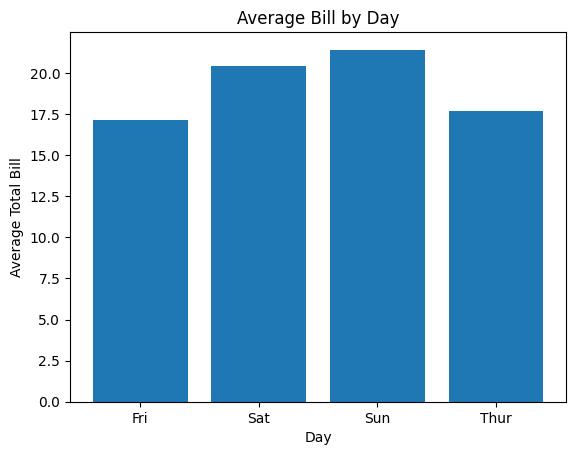

In [30]:
avg_by_day = tips.groupby('day')['total_bill'].mean()

plt.figure()
plt.bar(avg_by_day.index.astype(str), avg_by_day.values)
plt.title("Average Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.show()


### Student Practice

Create a bar chart showing average `tip_pct` by `time` (Lunch vs Dinner). Give it a title and axis labels.


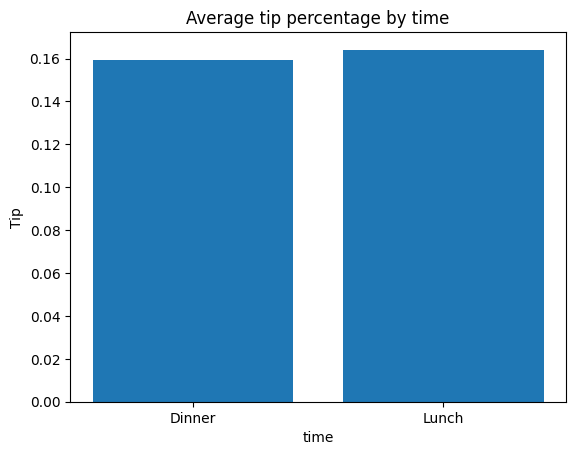

In [31]:
avg=tips.groupby('time')['tip_pct'].mean()
plt.figure()
plt.bar(avg.index,avg.values)
plt.title("Average tip percentage by time")
plt.xlabel("time")
plt.ylabel("Tip")
plt.show()

## Part 10: Saving Your Work

### Demonstration


In [32]:
summary = tips.groupby('day').agg(
    avg_bill=('total_bill','mean'),
    avg_tip=('tip','mean')
).round(2)

summary.to_csv('day_summary.csv')
print("Saved day_summary.csv")
summary


Saved day_summary.csv


,avg_bill,avg_tip
day,,
Fri,17.15,2.73
Sat,20.44,2.99
Sun,21.41,3.26
Thur,17.68,2.77


### Student Practice

Save a CSV called `my_time_summary.csv` containing the average `total_bill` and `tip_pct` grouped by `time`.


In [33]:
my_time=tips.groupby('time').agg(
    avg_total_bill=('total_bill','mean'),
    avg_tip_pct=('tip_pct','mean')
)
print("saved the csv")
my_time.to_csv("my_time_summary.csv")



saved the csv


**Reflection:** Why might you want to save intermediate results (like `summary`) to a CSV instead of just leaving them as a variable in the notebook?

*Your answer:*
the intermediate data may also be useful for other than the present task


# Mini Project A: Image Metadata Analysis (Image Track — continuing from NumPy lab)

Last week you analyzed a single image with NumPy (shape, brightness, RGB channels). Now you'll use pandas to compare **multiple images** at once — this is exactly how you'd organize a small image dataset for a computer vision project.

## Step 1: Build an image metadata table

For this project, upload **3-5 images** to Colab (reuse your NumPy lab technique), then build a DataFrame — one row per image — with columns: `filename`, `height`, `width`, `channels`, `avg_brightness`, `avg_red`, `avg_green`, `avg_blue`.

### Demonstration: the pattern for one image


In [34]:
from google.colab import files
uploaded = files.upload()



Saving srm logo.png to srm logo.png


In [42]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
print("Uploaded files:", filenames)

# Demonstration: extract metadata for ONE image
sample_name = filenames[0]
img_array = np.array(Image.open(sample_name))

row = {
    'filename': sample_name,
    'height': img_array.shape[0],
    'width': img_array.shape[1],
    'channels': img_array.shape[2] if img_array.ndim == 3 else 1,
    'avg_brightness': np.mean(img_array),
    'avg_red': np.mean(img_array[:,:,0]) if img_array.ndim == 3 else np.mean(img_array),
    'avg_green': np.mean(img_array[:,:,1]) if img_array.ndim == 3 else np.mean(img_array),
    'avg_blue': np.mean(img_array[:,:,2]) if img_array.ndim == 3 else np.mean(img_array),
}
print(row)


Uploaded files: ['srm logo.png']
{'filename': 'srm logo.png', 'height': 557, 'width': 557, 'channels': 4, 'avg_brightness': np.float64(115.32229354486235), 'avg_red': np.float64(106.47030933218157), 'avg_green': np.float64(104.36636056844664), 'avg_blue': np.float64(80.19260658374402)}


### Student Practice

Loop over **all** uploaded `filenames` (not just the first one), build a `row` dictionary like above for each image, collect them into a list, and convert the list into a DataFrame using `pd.DataFrame(list_of_rows)`.


In [43]:
import numpy as np
import pandas as pd
from PIL import Image

list_of_rows = []

for sample_name in filenames:
    img = Image.open(sample_name)
    img_array = np.array(img)

    row = {
        'filename': sample_name,
        'height': img_array.shape[0],
        'width': img_array.shape[1],
        'channels': img_array.shape[2] if img_array.ndim == 3 else 1,
        'avg_brightness': np.mean(img_array),
        'avg_red': np.mean(img_array[:, :, 0]) if img_array.ndim == 3 else np.mean(img_array),
        'avg_green': np.mean(img_array[:, :, 1]) if img_array.ndim == 3 else np.mean(img_array),
        'avg_blue': np.mean(img_array[:, :, 2]) if img_array.ndim == 3 else np.mean(img_array)
    }

    list_of_rows.append(row)

df = pd.DataFrame(list_of_rows)

print(df)

       filename  height  width  channels  avg_brightness  avg_red  avg_green  \
0  srm logo.png     557    557         4         115.322   106.47    104.366   

   avg_blue  
0    80.193  


## Step 2: Analyze the image table with pandas

Once you have your image DataFrame, answer using pandas (not manual calculation):

1. Which image has the highest average brightness? (Hint: `.sort_values()` or `.idxmax()`)
2. What is the average brightness across all your images? (`.mean()`)
3. Create a bar chart comparing `avg_brightness` across all images (reuse Part 9's pattern).


Image with highest brightness: srm logo.png
Brightness: 115.32229354486235
Average brightness: 115.32229354486235


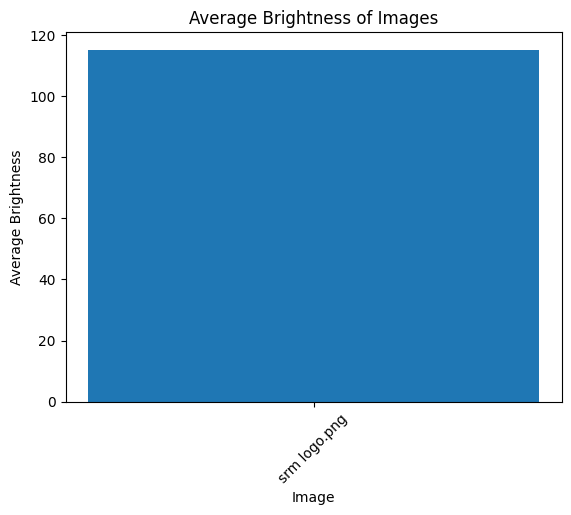

In [44]:
# 1. Image with the highest average brightness
brightest = df.loc[df['avg_brightness'].idxmax()]

print("Image with highest brightness:", brightest['filename'])
print("Brightness:", brightest['avg_brightness'])


# 2. Average brightness across all images
average_brightness = df['avg_brightness'].mean()

print("Average brightness:", average_brightness)


# 3. Bar chart comparing average brightness
import matplotlib.pyplot as plt

plt.bar(df['filename'], df['avg_brightness'])

plt.xlabel('Image')
plt.ylabel('Average Brightness')
plt.title('Average Brightness of Images')
plt.xticks(rotation=45)

plt.show()

**Reflection:** How is organizing multiple images into a DataFrame more useful than analyzing them one at a time like you did last week?

*Your answer:*


# Mini Project B: Word Frequency Table (NLP Track — continuing from NumPy lab)

Last week you built bag-of-words vectors and cosine similarity using raw NumPy. Now you'll organize word frequency data into a pandas DataFrame — the standard way this is done in real NLP pipelines.

## Step 1: Build a word frequency table

### Demonstration


In [45]:
sentence = "numpy makes numerical computing fast and numpy makes arrays powerful and pandas makes tables powerful"

tokens = sentence.lower().split()
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)

counts = [np.sum(tokens_array == word) for word in vocabulary]

word_freq = pd.DataFrame({'word': vocabulary, 'count': counts})
word_freq = word_freq.sort_values('count', ascending=False).reset_index(drop=True)
word_freq


,word,count
0,makes,3
1,and,2
2,powerful,2
3,numpy,2
4,arrays,1
5,computing,1
6,numerical,1
7,fast,1
8,pandas,1
9,tables,1


### Student Practice

1. Pick a paragraph of your own (3-4 sentences). Build a `word_freq` DataFrame for it using the same pattern.
2. Use pandas to find the top 5 most frequent words (`.head(5)`).
3. Use pandas to find how many words appear **only once** (Hint: filter where `count == 1`, then check `.shape[0]`).


In [47]:
paragraph = """Success does not come from talent alone; it grows through effort, courage, and perseverance.
When challenges appear, do not let failure convince you that your dreams are impossible.
Every setback can teach you something and every small step can move you closer to your goal.
Believe in your abilities, keep learning from your mistakes, and continue moving forward even when progress feels slow.
The people who keep trying after difficulties are often the ones who discover how much they are truly capable of achieving."""
tokens = paragraph.lower().replace(".", "").split()

tokens_array = np.array(tokens)

vocabulary = np.unique(tokens_array)

counts = [np.sum(tokens_array == word) for word in vocabulary]

word_freq = pd.DataFrame({'word': vocabulary, 'count': counts})

word_freq = word_freq.sort_values('count', ascending=False).reset_index(drop=True)

word_freq.head()

,word,count
0,your,4
1,and,3
2,you,3
3,are,3
4,the,2


## Step 2: Compare word frequency across multiple sentences

### Demonstration: build one table with per-sentence word counts


In [40]:
sentence_a = "machine learning uses numpy and pandas"
sentence_b = "deep learning also uses numpy and pandas heavily"

tokens_a = sentence_a.lower().split()
tokens_b = sentence_b.lower().split()
combined_vocab = np.unique(np.array(tokens_a + tokens_b))

table = pd.DataFrame({
    'word': combined_vocab,
    'sentence_a_count': [np.sum(np.array(tokens_a) == w) for w in combined_vocab],
    'sentence_b_count': [np.sum(np.array(tokens_b) == w) for w in combined_vocab],
})
table


,word,sentence_a_count,sentence_b_count
0,also,0,1
1,and,1,1
2,deep,0,1
3,heavily,0,1
4,learning,1,1
5,machine,1,0
6,numpy,1,1
7,pandas,1,1
8,uses,1,1


### Student Practice

Using the `table` above:
1. Add a new column `difference` = `sentence_a_count - sentence_b_count`.
2. Sort by `difference` to find which words are most unique to sentence A vs sentence B.
3. Which words appear in **both** sentences (count > 0 in both columns)? Filter and display them.


In [49]:
table['difference'] = table['sentence_a_count'] - table['sentence_b_count']
table = table.sort_values('difference', ascending=False)
print(table)

       word  sentence_a_count  sentence_b_count  difference
5   machine                 1                 0           1
7    pandas                 1                 1           0
1       and                 1                 1           0
6     numpy                 1                 1           0
4  learning                 1                 1           0
8      uses                 1                 1           0
0      also                 0                 1          -1
3   heavily                 0                 1          -1
2      deep                 0                 1          -1


**Reflection:** Compare this pandas approach to building the same information with raw NumPy arrays last week. What does pandas make easier, and what (if anything) does it hide from you that NumPy made explicit?

*Your answer:*

pandas is morely used to organise and sort data whilenumpy is mostly used for arthematic operations etc.

# Final Self-Check

- [ ] I loaded and inspected a real dataset using pandas
- [ ] I filtered, sorted, and created new columns myself
- [ ] I cleaned data (duplicates, missing values, dtypes, renaming) without just copying the demo
- [ ] I used `groupby()` to summarize data by category
- [ ] I merged two tables together
- [ ] I built at least one chart from a DataFrame
- [ ] I completed Mini Project A (image metadata) or B (word frequency), building the DataFrame myself
- [ ] I answered all reflection questions in my own words

## Final Reflection Questions

1. How is a pandas DataFrame related to a NumPy array? (Think back to last week's lab.)

2. Name one pandas operation that would be painful to do with raw NumPy arrays and loops instead, and explain why.

3. Between the image metadata project and the word frequency project, which felt more like "real world data work" to you, and why?

4. What's one pandas concept from this lab you still feel shaky on? Be specific — this helps guide review.
